# Environment Setup & Database Connection
**WHAT:** Import libraries and connect to MySQL.
**WHY:** Python is used for advanced statistical testing and feature engineering. We use SQLAlchemy to securely connect to our database.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
import urllib.parse
import warnings
import os
from IPython.display import display

warnings.filterwarnings('ignore')

db_username = 'root'
db_password = urllib.parse.quote_plus('Rishi@02#07')
db_host = 'localhost'
db_port = '3306'
db_name = 'hospital_readmissions'

engine = create_engine(f"mysql+pymysql://{db_username}:{db_password}@{db_host}:{db_port}/{db_name}")
print("Successfully loaded modules and connected to SQL.")


Successfully loaded modules and connected to SQL.


#  Initial Data Inspection
**WHAT:** Inspect the basic shape, data types, and summary statistics.
**WHY:** Before any transformations, a senior analyst must understand the raw dataset's structure, identify continuous vs categorical variables, and spot obvious anomalies.


In [ ]:
query = "SELECT * FROM vw_readmission_analysis"
df = pd.read_sql(query, engine)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types:")
display(df.dtypes)
print("\nDataFrame Info:")
display(df.info())
print("\nSummary Statistics:")
display(df.describe(include='all').T)

print("\nFirst 5 Rows:")
display(df.head())
print("\nLast 5 Rows:")
display(df.tail())


# Validation & Duplicate Analysis
**WHAT:** Check for duplicate rows and multiple encounters per patient.
**WHY:** In healthcare data, a "duplicate row" (exact same data twice) is an error. However, "duplicate encounter IDs" or "multiple encounters for one patient" are legitimate. We must NOT blindly drop duplicates without investigating. The MySQL layer already handled exact row deduplication, but we must verify.


In [19]:
print(f"Total Rows: {len(df)}")
print(f"Unique Encounters: {df['encounter_id'].nunique()}")
print(f"Unique Patients: {df['patient_nbr'].nunique()}")

exact_duplicates = df.duplicated().sum()
print(f"Exact Duplicate Rows: {exact_duplicates}")

encounter_dupes = df['encounter_id'].duplicated().sum()
print(f"Duplicate Encounter IDs: {encounter_dupes}")

# Interview Note: If duplicate encounter IDs existed, we would inspect them using:
# df[df['encounter_id'].duplicated(keep=False)].sort_values('encounter_id')


Total Rows: 99343
Unique Encounters: 99343
Unique Patients: 69990
Exact Duplicate Rows: 0
Duplicate Encounter IDs: 0


# Missing Value Analysis
**WHAT:** Identify nulls and calculate missing percentages.
**WHY:** We do NOT blindly impute missing data. For example, missing A1C means the test wasn't ordered�that is clinical information, not just "missing data".


In [20]:
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percentage': missing_pct
}).sort_values('missing_count', ascending=False)

display(missing_summary[missing_summary['missing_count'] > 0])


,missing_count,missing_percentage
diag_3,1419,1.428384
diag_2,356,0.358354
diagnosis_category,20,0.020132
diag_1,20,0.020132


# Data Type & Categorical Validation
**WHAT:** Ensure numeric columns are actually numeric, and validate categorical columns (gender, race, age, A1C, change, etc). Ensure binary targets only contain 0 and 1.
**WHY:** Pandas sometimes reads numeric columns as strings if they contain nulls or dirty characters. Validating categorical unique values ensures there are no hidden spelling mistakes (e.g. 'Male' vs 'male').


In [21]:
# Convert known numeric columns safely
numeric_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 
                'number_diagnoses', 'number_inpatient', 'number_emergency', 'number_outpatient']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Validate categorical columns
cat_cols = ['gender', 'race', 'age', 'readmitted', 'A1Cresult', 'medication_change', 'diagnosis_category']
for col in cat_cols:
    print(f"\n--- {col} Value Counts ---")
    display(df[col].value_counts(dropna=False))

# Validate target variable
assert df['is_readmitted_30'].isin([0, 1]).all(), "Target variable contains invalid values!"
print("\nTarget variable 'is_readmitted_30' validated successfully (contains only 0 and 1).")



--- gender Value Counts ---


gender
Female             53454
Male               45886
Unknown/Invalid        3
Name: count, dtype: int64


--- race Value Counts ---


race
Caucasian          74220
AfricanAmerican    18772
Unknown             2234
Hispanic            2017
Other               1472
Asian                628
Name: count, dtype: int64


--- age Value Counts ---


...


--- medication_change Value Counts ---


medication_change
No    53221
Ch    46122
Name: count, dtype: int64


--- diagnosis_category Value Counts ---


diagnosis_category
Other            30269
Circulatory      29585
Respiratory       9919
Digestive         9072
Diabetes          8661
Injury            6854
Genitourinary     4963
NaN                 20
Name: count, dtype: int64


Target variable 'is_readmitted_30' validated successfully (contains only 0 and 1).


# Feature Engineering
**WHAT:** Create meaningful clinical and utilization features.
**WHY:** Raw numbers (like `num_medications = 24`) are often less meaningful than clinical buckets (like `High Medication Burden`). 
*Note:* The analytical risk score is for segmentation only, NOT a clinically validated predictive model.


In [22]:
# Phase 9: Readmission Status
status_map = {'<30': 'Readmitted <30 Days', '>30': 'Readmitted >30 Days', 'NO': 'Not Readmitted'}
df['readmission_status'] = df['readmitted'].map(status_map)

# Phase 10: Medication Burden
df['medication_burden_tier'] = pd.cut(df['num_medications'], bins=[0, 10, 20, np.inf], labels=['Low', 'Medium', 'High'])

# Phase 11: Diagnosis Complexity
df['diagnosis_complexity_tier'] = pd.cut(df['number_diagnoses'], bins=[0, 5, 9, np.inf], labels=['Low Complexity', 'Moderate Complexity', 'High Complexity'])

# Phase 12: Prior Utilization
df['prior_utilization_total'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']
df['utilization_tier'] = pd.cut(df['prior_utilization_total'], bins=[-1, 0, 2, np.inf], labels=['None', 'Low', 'High'])

# Phase 13: Simple Analytical Score (0-3 scale based on tiers)
df['analytical_risk_score'] = (
    (df['medication_burden_tier'] == 'High').astype(int) + 
    (df['diagnosis_complexity_tier'] == 'High Complexity').astype(int) + 
    (df['utilization_tier'] == 'High').astype(int)
)


# Outlier Analysis
**WHAT:** Investigate potentially unusual values in numerical features (time_in_hospital, num_medications, etc).
**WHY:** We do not automatically delete outliers. High number of medications or long stays are legitimate clinical observations for severely ill patients, not necessarily data errors. We examine them to decide.


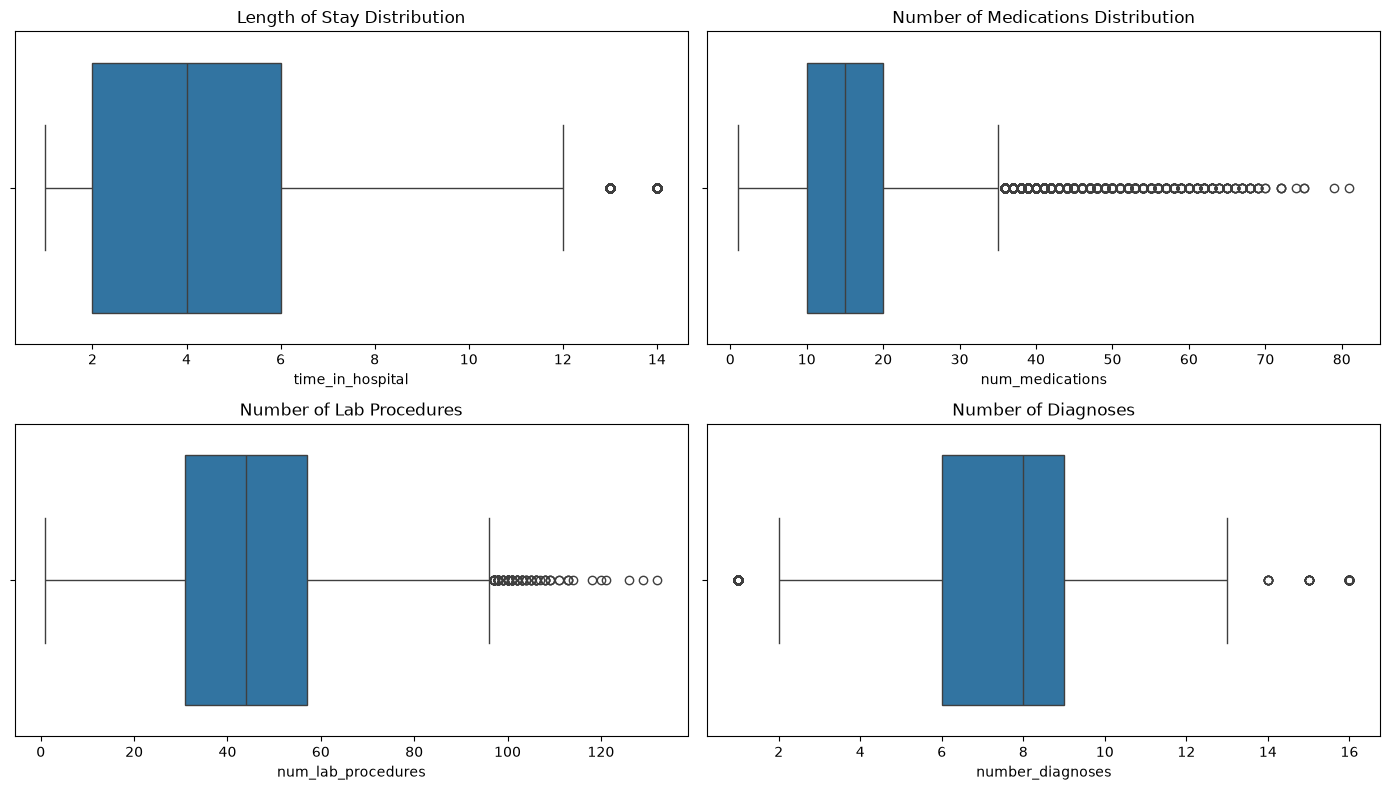

Outlier Decision: Although there are values beyond the IQR whiskers, these represent highly complex clinical cases. Deleting them would bias our readmission analysis against the sickest patients. They will be kept.


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=df, x='time_in_hospital', ax=axes[0,0])
axes[0,0].set_title('Length of Stay Distribution')

sns.boxplot(data=df, x='num_medications', ax=axes[0,1])
axes[0,1].set_title('Number of Medications Distribution')

sns.boxplot(data=df, x='num_lab_procedures', ax=axes[1,0])
axes[1,0].set_title('Number of Lab Procedures')

sns.boxplot(data=df, x='number_diagnoses', ax=axes[1,1])
axes[1,1].set_title('Number of Diagnoses')

plt.tight_layout()
plt.show()

print("Outlier Decision: Although there are values beyond the IQR whiskers, these represent highly complex clinical cases. Deleting them would bias our readmission analysis against the sickest patients. They will be kept.")


# Exploratory Data Analysis
**WHAT:** Build a reusable function to calculate readmission rates across different groups and apply it.
**WHY:** DRY (Don't Repeat Yourself) principle. A reusable function ensures consistency across all features.


In [24]:
def readmission_summary(df, group_col):
    summary = df.groupby(group_col).agg(
        total_encounters=('encounter_id', 'count'),
        readmissions_30=('is_readmitted_30', 'sum')
    ).reset_index()
    summary['readmission_rate_pct'] = (summary['readmissions_30'] / summary['total_encounters']) * 100
    return summary.sort_values('readmission_rate_pct', ascending=False)

eda_cols = ['age', 'gender', 'race', 'diagnosis_category', 'A1Cresult', 'medication_change', 'medication_burden_tier', 'diagnosis_complexity_tier', 'utilization_tier']
for col in eda_cols:
    print(f"\n=== Readmission Rate by {col} ===")
    display(readmission_summary(df, col))



=== Readmission Rate by age ===


,age,total_encounters,readmissions_30,readmission_rate_pct
2,[20-30),1649,236,14.311704
8,[80-90),16434,2065,12.565413
7,[70-80),25331,3054,12.056374
9,[90-100),2589,308,11.896485
6,[60-70),22059,2493,11.301510
3,[30-40),3764,424,11.264612
4,[40-50),9607,1024,10.658895
5,[50-60),17060,1667,9.771395
1,[10-20),690,40,5.797101
0,[0-10),160,3,1.875000



=== Readmission Rate by gender ===


,gender,total_encounters,readmissions_30,readmission_rate_pct
0,Female,53454,6128,11.464063
1,Male,45886,5186,11.301922
2,Unknown/Invalid,3,0,0.000000



=== Readmission Rate by race ===


...

,medication_burden_tier,total_encounters,readmissions_30,readmission_rate_pct
2,High,23089,3044,13.183767
1,Medium,50942,5938,11.656394
0,Low,25312,2332,9.213021



=== Readmission Rate by diagnosis_complexity_tier ===


,diagnosis_complexity_tier,total_encounters,readmissions_30,readmission_rate_pct
2,High Complexity,109,17,15.596330
1,Moderate Complexity,78370,9515,12.141125
0,Low Complexity,20864,1782,8.541028



=== Readmission Rate by utilization_tier ===


,utilization_tier,total_encounters,readmissions_30,readmission_rate_pct
2,High,15460,3003,19.424321
1,Low,29207,3760,12.873626
0,None,54676,4551,8.323579


# Statistical Analysis & Confidence Intervals
**WHAT:** Use Chi-Square tests for categorical vs categorical, Mann-Whitney U for continuous vs categorical, and Confidence Intervals.
**WHY:** Prove findings are statistically significant. 
*Note on Causation:* We state that variables are **associated** with readmissions, not that they **cause** them.


In [25]:
# 1. Confidence Interval for Overall Readmission Rate
overall_rate = df['is_readmitted_30'].mean()
n = len(df['is_readmitted_30'])
se = np.sqrt((overall_rate * (1 - overall_rate)) / n)
ci_lower, ci_upper = stats.norm.interval(0.95, loc=overall_rate, scale=se)
print(f"Overall Readmission Rate: {overall_rate*100:.2f}% (95% CI: {ci_lower*100:.2f}% - {ci_upper*100:.2f}%)")

# 2. Chi-Square Test (Medication Burden vs Readmission)
contingency_table = pd.crosstab(df['medication_burden_tier'], df['is_readmitted_30'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square p-value for Medication Burden: {p_val:.2e}")

# 3. Chi-Square Test (Diagnosis Category vs Readmission)
contingency_diag = pd.crosstab(df['diagnosis_category'], df['is_readmitted_30'])
chi2_diag, p_val_diag, dof_diag, expected_diag = stats.chi2_contingency(contingency_diag)
print(f"Chi-Square p-value for Diagnosis Category: {p_val_diag:.2e}")

# 4. Mann-Whitney U Test (Length of Stay vs Readmission)
stay_readmit = df[df['is_readmitted_30'] == 1]['time_in_hospital'].dropna()
stay_noreadmit = df[df['is_readmitted_30'] == 0]['time_in_hospital'].dropna()
stat, p_val2 = stats.mannwhitneyu(stay_readmit, stay_noreadmit, alternative='two-sided')
print(f"Mann-Whitney p-value for Length of Stay: {p_val2:.2e}")


Overall Readmission Rate: 11.39% (95% CI: 11.19% - 11.59%)
Chi-Square p-value for Medication Burden: 2.66e-43
Chi-Square p-value for Diagnosis Category: 4.77e-10
Mann-Whitney p-value for Length of Stay: 1.54e-62


# Visual EDA 
**WHAT:** Create plots to visually validate our statistical findings.
**WHY:** Visuals help stakeholders quickly grasp trends. (These will be recreated interactively in Power BI).


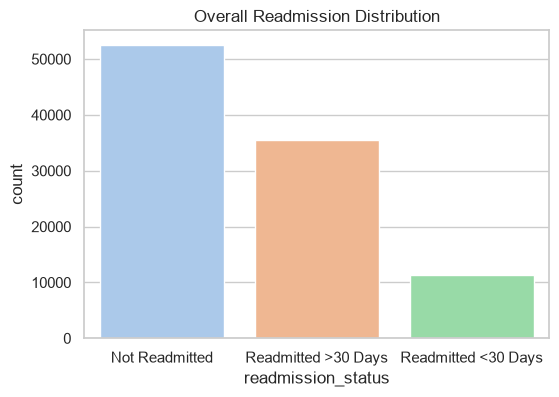

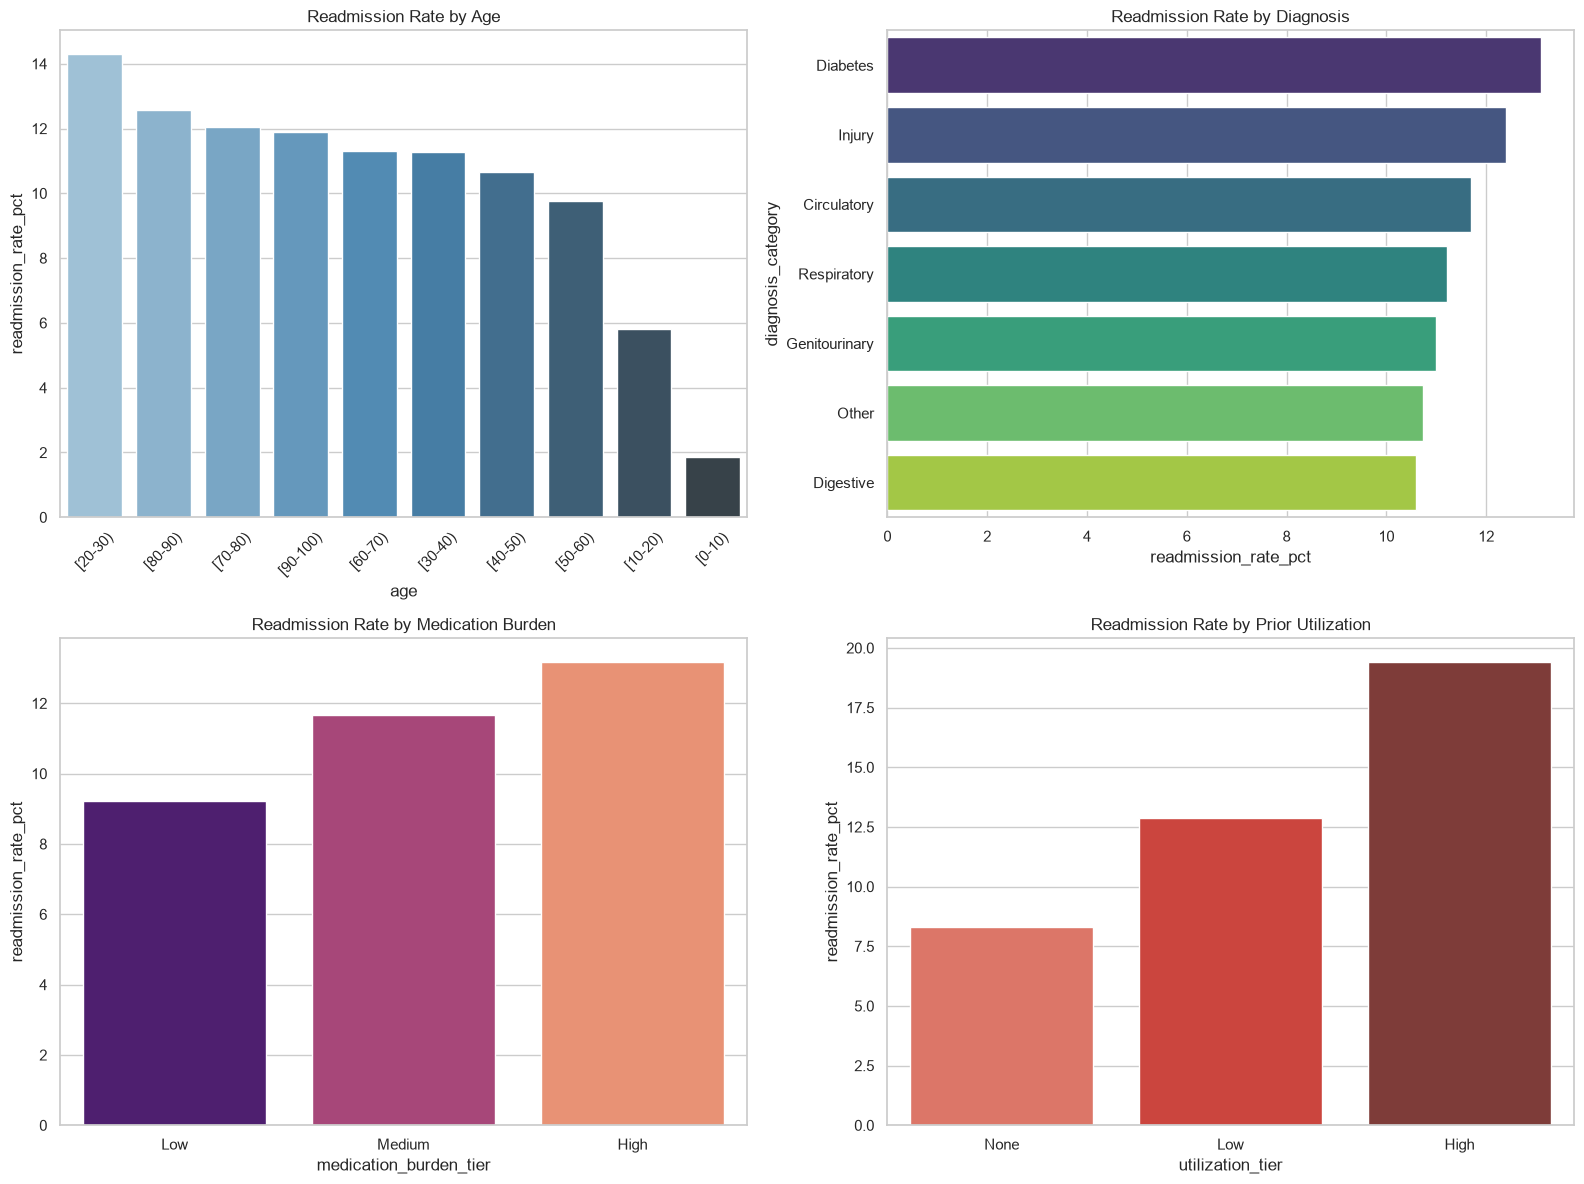

In [26]:
sns.set_theme(style="whitegrid")

# Readmission Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='readmission_status', palette='pastel')
plt.title('Overall Readmission Distribution')
plt.show()

# Multi-plot EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=readmission_summary(df, 'age'), x='age', y='readmission_rate_pct', ax=axes[0,0], palette='Blues_d')
axes[0,0].set_title('Readmission Rate by Age')
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(data=readmission_summary(df, 'diagnosis_category'), y='diagnosis_category', x='readmission_rate_pct', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Readmission Rate by Diagnosis')

sns.barplot(data=readmission_summary(df, 'medication_burden_tier'), x='medication_burden_tier', y='readmission_rate_pct', ax=axes[1,0], palette='magma')
axes[1,0].set_title('Readmission Rate by Medication Burden')

sns.barplot(data=readmission_summary(df, 'utilization_tier'), x='utilization_tier', y='readmission_rate_pct', ax=axes[1,1], palette='Reds_d')
axes[1,1].set_title('Readmission Rate by Prior Utilization')

plt.tight_layout()
plt.show()


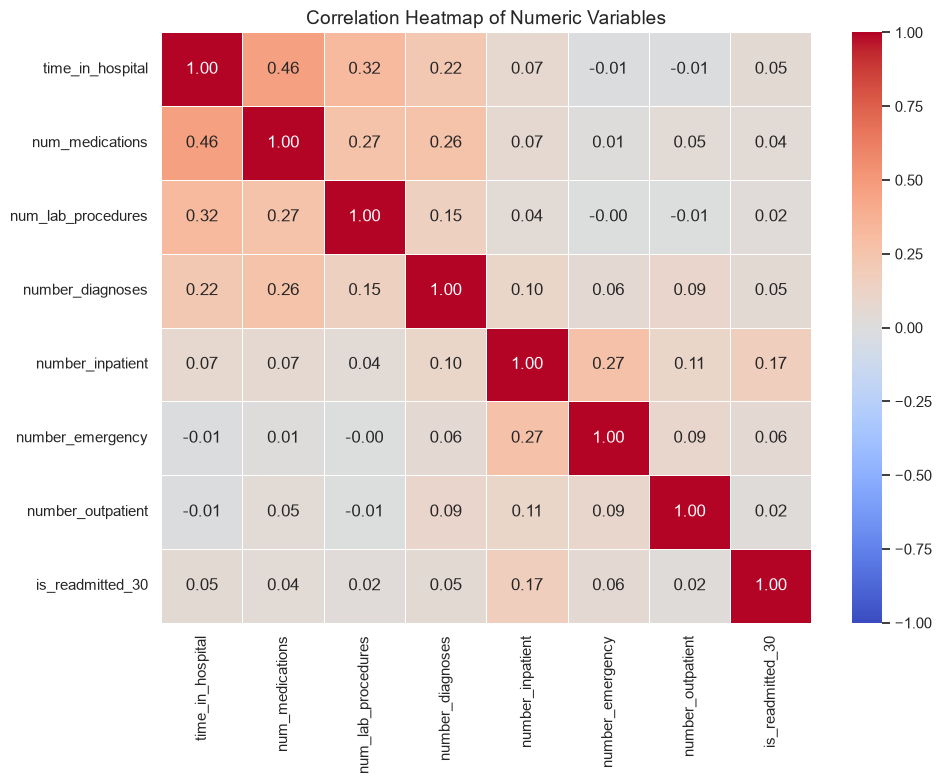

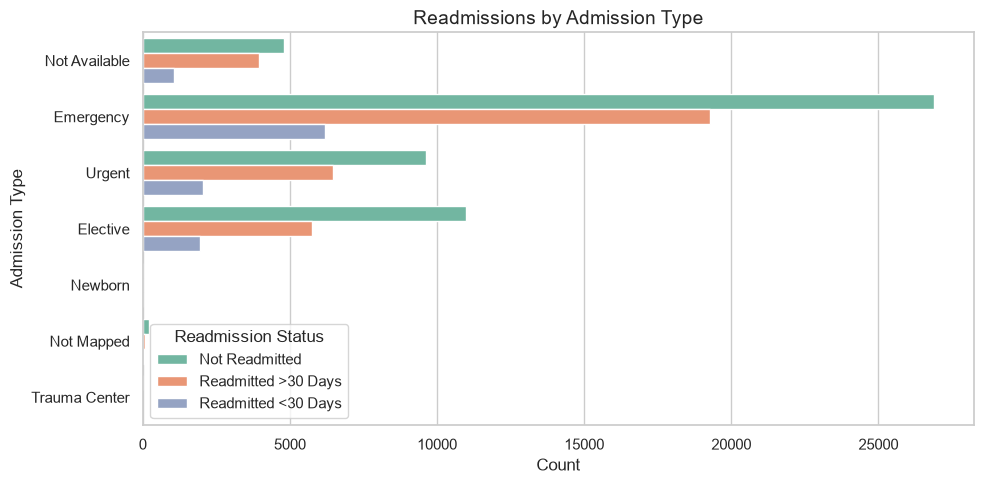

In [28]:
# 1. Correlation Heatmap
corr_cols = [
    'time_in_hospital', 'num_medications', 'num_lab_procedures', 
    'number_diagnoses', 'number_inpatient', 'number_emergency', 
    'number_outpatient', 'is_readmitted_30'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Additional Visualization: Admission Type vs Readmission
if 'admission_type' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y='admission_type', hue='readmission_status', palette='Set2')
    plt.title('Readmissions by Admission Type', fontsize=14)
    plt.xlabel('Count')
    plt.ylabel('Admission Type')
    plt.legend(title='Readmission Status')
    plt.tight_layout()
    plt.show()


# Data Leakage Check
**WHAT:** Ensure we aren't using future information to predict past events.
**WHY:** `discharge_disposition` is known at the *end* of the encounter. If we were building a predictive model for use *at admission*, using `discharge_disposition` would be Data Leakage. Since this is a descriptive analysis, it is safe to keep.


# Final Dataset Validation & Export
**WHAT:** Select only validated columns, run final assertions, and export for Power BI.
**WHY:** Power BI should consume clean, structured, validated data. Pushing Python transformations downstream ensures the BI layer remains light and performant. Power BI should directly consume this CSV for simplicity and speed in a portfolio setting.


In [27]:
# Select Final Columns
final_cols = [
    'encounter_id', 'patient_nbr', 'age', 'age_midpoint', 'gender', 'race', 
    'admission_type', 'admission_source', 'discharge_disposition', 
    'time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_diagnoses', 
    'number_inpatient', 'number_emergency', 'number_outpatient', 'diagnosis_category', 
    'A1Cresult', 'medication_change', 'readmitted', 'is_readmitted_30', 
    'readmission_status', 'medication_burden_tier', 'diagnosis_complexity_tier', 
    'prior_utilization_total', 'analytical_risk_score'
]
df_powerbi = df[final_cols].copy()

# Final Validations
assert df_powerbi['encounter_id'].is_unique, "Critical Error: Duplicate encounters found!"
assert df_powerbi['is_readmitted_30'].isin([0, 1]).all(), "Critical Error: Invalid target values!"

# Export
os.makedirs('../data/cleaned_data', exist_ok=True)
output_path = '../data/cleaned_data/readmission_analysis_powerbi.csv'
df_powerbi.to_csv(output_path, index=False)
print(f"Validated dataset successfully exported to: {output_path}")
print(f"Final shape: {df_powerbi.shape}")


Validated dataset successfully exported to: ../data/cleaned_data/readmission_analysis_powerbi.csv
Final shape: (99343, 26)
